In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('../data/kodama_plink_gwas_runtime.tsv', sep='\t')
df

,method,node,region,dataset,runtime,peak_mem
0,plink,mem3_ssd1_v2_x32,chr1,common,35860.00,6609.89
1,plink,mem3_ssd1_v2_x32,chr2,common,38017.00,6677.08
2,plink,mem3_ssd1_v2_x32,chr3,common,37650.00,6620.50
3,plink,mem3_ssd1_v2_x32,chr4,common,33697.00,6626.53
4,plink,mem3_ssd1_v2_x32,chr5,common,29274.00,6573.45
5,plink,mem3_ssd1_v2_x32,chr6,common,30549.00,6599.75
6,plink,mem3_ssd1_v2_x32,chr7,common,27032.00,6606.42
7,plink,mem3_ssd1_v2_x32,chr8,common,24915.00,6690.61
8,plink,mem3_ssd1_v2_x32,chr9,common,19056.00,6570.29
9,plink,mem3_ssd1_v2_x32,chr10,common,23640.00,6621.24


In [3]:
names = {
    'kodama-gwas': 'kodama-gwas',
    'kodama-gwas-rv': 'kodama-gwas-rv',
    'plink-qtr': 'PLINK 2.0 qt-residualize',
    'plink': 'PLINK 2.0',
}

colors = {
    'kodama-gwas': '#56C1FF', # blue
    'kodama-gwas-rv': '#A8C256', # green
    'plink': '#E9B824', # yellow,
    'plink-qtr': '#e67487', # pink
}

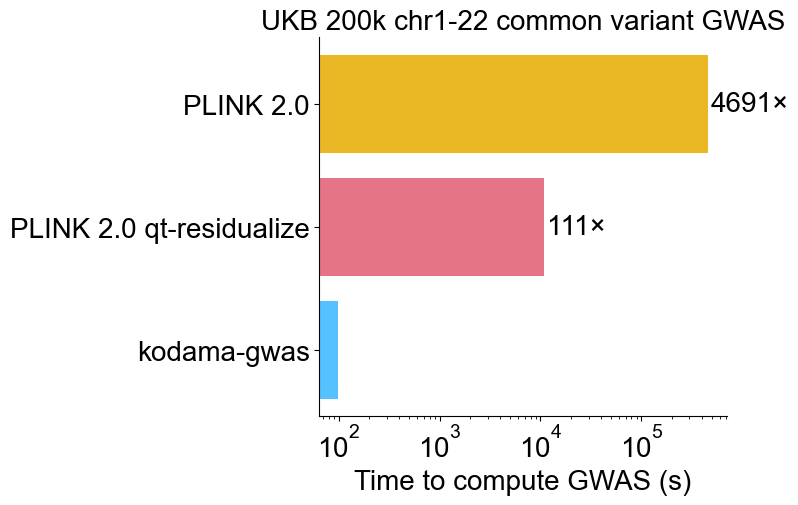

{'kodama-gwas': np.float64(98.29), 'plink-qtr': np.float64(10955.489999999998), 'plink': np.float64(461086.0)}


In [ ]:
times = {
    'kodama-gwas': df[(df.method=='kodama-gwas') & (df.dataset=='common')].runtime.iloc[0],
    'plink-qtr': np.sum(df[(df.method=='plink_qtr') & (df.dataset=='common')].runtime),
    'plink': np.sum(df[(df.method=='plink') & (df.dataset=='common')].runtime),
}

methods = ['kodama-gwas', 'plink-qtr', 'plink']

kodama_time = times['kodama-gwas']


fig, ax = plt.subplots(figsize=(8, 5))

ypos = np.arange(len(methods))

for i, m in enumerate(methods):
    ax.barh(ypos[i], times[m], color=colors[m])

for i, m in enumerate(methods):
    if m == 'kodama-gwas':
        continue
    else:
        s1 = times[m] / kodama_time
        ax.text(times[m] * 1.05, ypos[i],
                f"{int(round(s1))}×",
                va='center', fontsize=20)

ax.set_yticks(ypos)
ax.set_yticklabels([names[m] for m in methods], fontsize=20)
ax.set_xlabel('Time to compute GWAS (s)', fontsize=20)
ax.set_title('UKB 200k chr1-22 common variant GWAS', fontsize=20)

plt.xscale('log')
plt.tight_layout()

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='x', labelsize=20)

plt.show()
print(times)

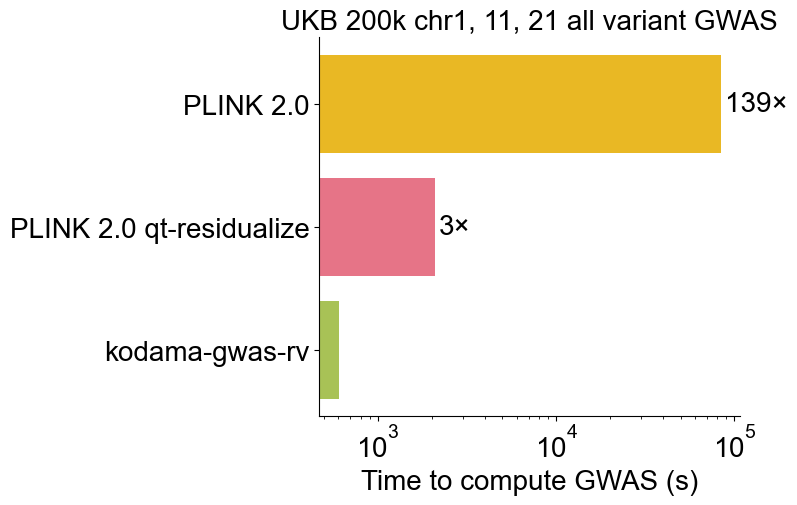

{'kodama-gwas-rv': np.float64(601.69), 'plink-qtr': np.float64(2096.9700000000003), 'plink': np.float64(83883.0)}


In [ ]:
times = {
    'kodama-gwas-rv': df[(df.method=='kodama-gwas-rv') & (df.dataset=='all')].runtime.iloc[0],
    'plink-qtr': np.sum(df[(df.method=='plink_qtr') & (df.dataset=='all')].runtime),
    'plink': np.sum(df[(df.method=='plink') & (df.dataset=='all')].runtime),
}

methods = ['kodama-gwas-rv', 'plink-qtr', 'plink']

kodama_time = times['kodama-gwas-rv']


fig, ax = plt.subplots(figsize=(8, 5))

ypos = np.arange(len(methods))

for i, m in enumerate(methods):
    ax.barh(ypos[i], times[m], color=colors[m])

for i, m in enumerate(methods):
    if m == 'kodama-gwas-rv':
        continue
    else:
        s1 = times[m] / kodama_time
        ax.text(times[m] * 1.05, ypos[i],
                f"{int(round(s1))}×",
                va='center', fontsize=20)

ax.set_yticks(ypos)
ax.set_yticklabels([names[m] for m in methods], fontsize=20)
ax.set_xlabel('Time to compute GWAS (s)', fontsize=20)
ax.set_title('UKB 200k chr1, 11, 21 all variant GWAS', fontsize=20)

plt.xscale('log')
plt.tight_layout()

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='x', labelsize=20)

plt.show()
print(times)